# SpiderNet data loading and MI-dimension-selection tutorial

This notebook is a step-by-step tutorial for loading and preprocessing spatial transcriptomics data for SpiderNet, as well as running the mutual information (MI) dimension selection procedure on the processed data.

1. **Basic user inputs**
2. **Standard SpiderNet input assumptions**
3. **Build the base config**
4. **Preview the LR-correlation density before choosing `lr_corr_threshold`**
5. **Run the full unified loader**
6. **Inspect outputs**
7. **Save HGSOC-specific sample metadata**
8. **Run MI dimension selection on the processed outputs**


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import scanpy as sc

# If the notebook is run from the project root, this is usually enough.
sys.path.append(str(Path.cwd()))

from SpiderNet.dataloading_unified import (
    prepare_processed_bundle_unified,
    preview_lr_corr_distribution,
)
from SpiderNet.utils import (
    get_default_cellchat_db,
    get_default_scseqcomm_db,
)


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Step 1. Basic user inputs

Edit the variables in this section first.


In [2]:
DATA_ROOT = Path("D:/SpiderNet/Data/HGSOC") ## Set this to your local data directory
OUTPUT_DIR = Path("D:/SpiderNet/Results/HGSOC/ProcessedData") ## Set this to your desired processed data directory

SPECIES = "human" ## Set this to your species, used for ligand-receptor database loading. Options are "human" or "mouse".

SAMPLE_COL = "samples" ## Set this to the column in adata.obs that defines the sample labels (i.e. which cells belong to the same sample)
CELL_CLASS_COL = "cell.types" ## Set this to the column in adata.obs that defines the cell type annotation
PYG_EXTRA_OBS_FIELDS = {"patients": "patients"} ## Set this to a dict of {new_field_name: adata.obs column name} for any extra adata.obs fields you want copied into each PyG sample object. For example, {"patients": "patients"} means that adata.obs["patients"] will also be stored in each PyG sample object under data.patients.

N_HVG = 1000 ## Number of top highly variable genes used as SpiderNet model input for training
N_HVG_LR = 2000 ## Number of top highly variable genes used to define the candidate ligand-receptor search space; LR pairs are selected only if their genes are within these top genes
NUM_NEIGHBORS = 10 ## Number of spatial neighbors

# Set this only after running the preview section below
LR_CORR_THRESHOLD = None ## Set this to the desired ligand-receptor correlation threshold after inspecting the preview plot in Step 4. Common choices are around 0.5, but it depends on the dataset and the preview plot.

# Optional advanced override:
# Leave this as None for the standard SpiderNet input convention:
#   - raw counts stored in layers["counts"]
#   - spatial coordinates stored in obsm["spatial"]
# If your input AnnData only has a pre-normalized layer, set it here
# (for example, "normalizedexp"), and the notebook will skip normalize/log1p.
PRENORMALIZED_LAYER = None


## Step 2. Standard SpiderNet input

This notebook assumes the standard SpiderNet-ready AnnData format:

- raw counts are stored in `layers["counts"]`
- spatial coordinates are stored in `obsm["spatial"]`
- samples are defined by `obs[SAMPLE_COL]`

Because this convention is expected by the tutorial, these settings are kept out of the main
user-input block above.

If your data does **not** contain raw counts and only contains pre-normalized expression,
set `PRENORMALIZED_LAYER` in **Step 1**. The notebook will then read that layer directly and
skip `normalize_total` and `log1p`.


In [3]:
CELLCHAT_DB = get_default_cellchat_db(species=SPECIES)
SCSEQCOMM_DB = get_default_scseqcomm_db(species=SPECIES)

if PRENORMALIZED_LAYER is None:
    DATA_REPRESENTATION_CONFIG = {
        "expression_source": {"kind": "layer", "name": "counts"},
        "normalize_strategy": "always",
        "log1p": True,
        "remove_zero_count_cells": False,
    }
else:
    DATA_REPRESENTATION_CONFIG = {
        "expression_source": {"kind": "layer", "name": PRENORMALIZED_LAYER},
        "normalize_strategy": "never",
        "log1p": False,
        "remove_zero_count_cells": False,
    }


## Step 3. Build the base config

This config contains the common loading settings.
`lr_corr_threshold` is intentionally left unset until after the preview step.


In [4]:
base_config = {
    "data_path_main": DATA_ROOT,
    "output_dir": OUTPUT_DIR,
    "ligand_receptor_filedir_cellchatdb": CELLCHAT_DB,
    "ligand_receptor_filedir_scSeqComm": SCSEQCOMM_DB,

    "sample_col": SAMPLE_COL,
    "cell_class_col": CELL_CLASS_COL,
    "pyg_obs_fields": PYG_EXTRA_OBS_FIELDS,

    "n_hvg": N_HVG,
    "n_hvg_lr": N_HVG_LR,
    "num_neighbors": NUM_NEIGHBORS,

    # Keep unset until after the preview
    "lr_corr_threshold": LR_CORR_THRESHOLD,
}

base_config.update(DATA_REPRESENTATION_CONFIG)

print("CellChat DB:", CELLCHAT_DB)
print("scSeqComm DB:", SCSEQCOMM_DB)
print("Base output dir:", OUTPUT_DIR)

pd.Series({
    "data_path_main": str(base_config["data_path_main"]),
    "output_dir": str(base_config["output_dir"]),
    "sample_col": base_config["sample_col"],
    "cell_class_col": base_config["cell_class_col"],
    "n_hvg": base_config["n_hvg"],
    "n_hvg_lr": base_config["n_hvg_lr"],
    "num_neighbors": base_config["num_neighbors"],
    "expression_source": str(base_config["expression_source"]),
    "normalize_strategy": base_config["normalize_strategy"],
}).to_frame("value")


CellChat DB: D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\resources\Human_LR_pairs_Cellchatdb.csv
scSeqComm DB: D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\resources\Human_LR_pairs_scSeqComm.csv
Base output dir: D:\SpiderNet\Results\HGSOC\ProcessedData


,value
data_path_main,D:\SpiderNet\Data\HGSOC
output_dir,D:\SpiderNet\Results\HGSOC\ProcessedData
sample_col,samples
cell_class_col,cell.types
n_hvg,1000
n_hvg_lr,2000
num_neighbors,10
expression_source,"{'kind': 'layer', 'name': 'counts'}"
normalize_strategy,always


## Step 4. Preview the LR-correlation density

Run this cell **before** setting `LR_CORR_THRESHOLD`.

This preview only runs the minimal preprocessing needed to reach the LR-correlation stage.
It does **not** run the full `prepare_processed_bundle_unified(...)` pipeline, and it only shows
the density plot needed for choosing `lr_corr_threshold`.


Preview: load the data and run up to the LR-correlation stage
Reading AnnData files from: D:\SpiderNet\Data\HGSOC\adata


D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\dataloading_unified.py:575: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = sc.AnnData.concatenate(*adata_file_list, batch_key="_concat_batch", index_unique=None)
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\merge.py:1651: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\merge.py:1651: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is

Number of ligand-receptor pairs from CellChatDB: 541
Total number of Ligand–Receptor pairs after direct CellChat selection and branch-local deduplication: 479


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


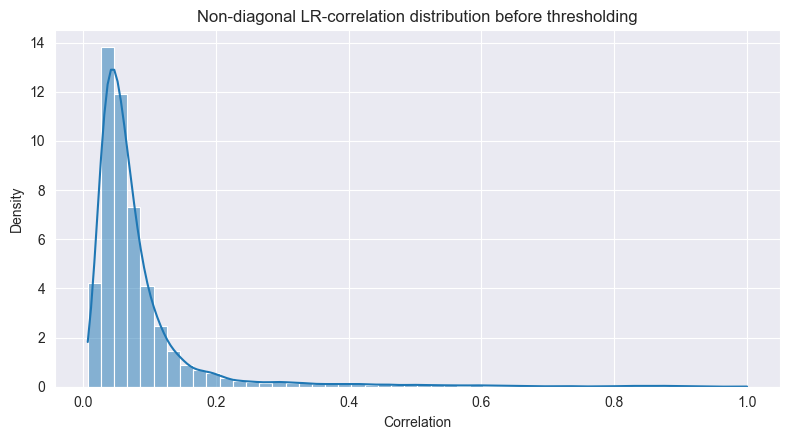

Preview plot saved to: D:\SpiderNet\Results\HGSOC\ProcessedData\_lr_corr_preview\LR_corr_distribution_before_threshold.png


In [5]:
preview = preview_lr_corr_distribution(base_config, show_plot=True)

if preview.get("plot_path") is not None:
    print("Preview plot saved to:", preview["plot_path"])


## Step 5. Set `lr_corr_threshold` and run the full loader

After inspecting the density plot above, set `LR_CORR_THRESHOLD` to the desired value (commonly around 0.5, but it depends on the dataset and the preview plot), then run this cell to execute the full unified loading pipeline.


In [6]:
LR_CORR_THRESHOLD = 0.5

In [7]:
if LR_CORR_THRESHOLD is None:
    raise ValueError(
        "Please set LR_CORR_THRESHOLD in Step 1 after inspecting the preview plot, "
        "then rerun Step 3 and this cell."
    )

config = dict(base_config)
config["lr_corr_threshold"] = float(LR_CORR_THRESHOLD)

bundle = prepare_processed_bundle_unified(config)


Step 1: Load the data and perform preprocessing
Reading AnnData files from: D:\SpiderNet\Data\HGSOC\adata
AnnData object with n_obs × n_vars = 5660 × 979
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'samples', 'patients', 'sites_binary', 'cell.types', 'cell.subtypes', 'x', 'y', 'SAMPLE_ID', 'CELL_TYPE', 'dataset', 'platform', 'n_cells', 'median_tpc', 'mean_tpc', 'TMA', 'age', 'stage', 'treatment', '1L', 'parpi', 'immunotherapy', 'fu_time1', 'fu_time2', 'outcome', 'pfs', 'BRCA1_Somatic', 'BRCA2_Somatic', 'TP53_Somatic', 'BRCA1_Germline', 'BRCA2_Germline', 'TP53_Germline', 'tmb'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts', 'data', 'scale.data'


D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\dataloading_unified.py:987: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = sc.AnnData.concatenate(*adata_file_list, batch_key="_concat_batch", index_unique=None)
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\merge.py:1651: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\merge.py:1651: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is

Number of ligand-receptor pairs from CellChatDB: 541
Total number of Ligand–Receptor pairs after direct CellChat selection and branch-local deduplication: 479
Step 2: Build sample-level SpiderNet data dictionaries
Step 3: Build spatial neighbor graph
Total number of edges across all samples: 2766680
Step 4: One-hot encoding of cell types and PyG object creation
Step 5: Compute cell–cell–LRpair tensor
Step 6: Filter LR pairs based on coverage across edges
Quantiles of LR pair activation proportion: [0.00124595 0.0163396  0.04638512 0.12309596 0.60915953]
Step 7: Compute pairwise LR correlation across samples


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Step 8: Finalize PyG features and cell labels
Step 9: Compute neighboring cell-type proportions
Step 11: Build batch-aligned adata_list
Step 12: Save processed objects
Done.


## Step 6. Inspect the processed outputs

In [8]:
print("Output dir:", bundle["output_dir"])
print("Number of batches:", len(bundle["batch_cell_unique"]))
print("Total cells:", bundle["adata"].n_obs)
print("All genes:", len(bundle["genenames"]))
print("Training genes:", len(bundle["genenames_train"]))
print("Training LR pairs:", len(bundle["LR_list"]))
print("Number of cell types:", bundle["adata"].obs[CELL_CLASS_COL].nunique())
print("Cell types:", bundle["adata"].obs[CELL_CLASS_COL].unique())

bundle["adata"].obs.head()


Output dir: D:\SpiderNet\Results\HGSOC\ProcessedData
Number of batches: 48
Total cells: 276668
All genes: 979
Training genes: 979
Training LR pairs: 185
Number of cell types: 7
Cell types: ['Malignant', 'Fibroblast', 'Monocyte', 'TNK.cell', 'B.cell', 'Endothelial', 'Mast.cell']
Categories (7, object): ['B.cell', 'Endothelial', 'Fibroblast', 'Malignant', 'Mast.cell', 'Monocyte', 'TNK.cell']


,orig.ident,nCount_RNA,nFeature_RNA,samples,patients,sites_binary,cell.types,cell.subtypes,x,y,...,TP53_Germline,tmb,_concat_batch,B.cell_prop,Endothelial_prop,Fibroblast_prop,Malignant_prop,Mast.cell_prop,Monocyte_prop,TNK.cell_prop
SMI_T10_F001_c1017,SMI,848.0,357,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,1493.3500,3151.233,...,US,6.8,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
SMI_T10_F001_c102,SMI,731.0,319,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,2623.2000,3607.450,...,US,6.8,0,0.0,0.0,0.1,0.7,0.0,0.2,0.0
SMI_T10_F001_c1062,SMI,236.0,155,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,850.5670,3143.833,...,US,6.8,0,0.0,0.0,0.1,0.8,0.0,0.1,0.0
SMI_T10_F001_c1064,SMI,609.0,300,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,3222.7300,3152.586,...,US,6.8,0,0.0,0.0,0.1,0.6,0.0,0.1,0.2
SMI_T10_F001_c1075,SMI,310.0,174,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,78.0125,3179.012,...,US,6.8,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Step 7. Save HGSOC-specific sample metadata

This is intentionally kept outside the unified loader because it is clearly
HGSOC-specific downstream metadata formatting.


In [9]:
metadata_sample = pd.read_csv(DATA_ROOT / "HGSOC_metadata.csv", index_col=0)

real_samples = np.sort(bundle["adata"].obs[SAMPLE_COL].astype(str).unique())

metadata_use = metadata_sample.loc[real_samples, :].copy()
metadata_use["stage_index"] = metadata_use["stage"].astype("category").cat.codes
metadata_use["treatment_index"] = metadata_use["treatment"].astype("category").cat.codes
metadata_use["sites_binary_index"] = metadata_use["sites_binary"].astype("category").cat.codes
metadata_use["outcome_use"] = metadata_use["outcome"].replace({"Dead of disease": "Dead (disease)"})
metadata_use["outcome_use_index"] = metadata_use["outcome_use"].astype("category").cat.codes
metadata_use["samples"] = metadata_use.index

metadata_use.to_csv(Path(bundle["output_dir"]) / "metadata_sample.csv", index=False)
metadata_use.head()


,dataset,platform,n_cells,median_tpc,mean_tpc,TMA,patients,sites_binary,age,stage,...,BRCA1_Germline,BRCA2_Germline,TP53_Germline,tmb,stage_index,treatment_index,sites_binary_index,outcome_use,outcome_use_index,samples
profile,,,,,,,,,,,,,,,,,,,,,
SMI_T10_F001,Discovery,SMI,5660,205.0,238.675618,TMA 10,HGSC1,Adnexa,58.0,III,...,US,US,US,6.80,1,0,0,Alive,0,SMI_T10_F001
SMI_T10_F002,Discovery,SMI,8821,364.0,393.318671,TMA 10,HGSC7,Adnexa,58.0,III,...,US,US,US,0.53,1,0,0,Alive,0,SMI_T10_F002
SMI_T10_F006,Discovery,SMI,5295,384.0,446.908404,TMA 10,HGSC2,Adnexa,36.0,IV,...,US,US,US,9.50,2,0,0,Alive,0,SMI_T10_F006
SMI_T10_F009,Discovery,SMI,2944,392.0,458.231318,TMA 10,HGSC11,Omentum,54.0,III,...,B,US,US,6.32,1,0,1,Alive,0,SMI_T10_F009
SMI_T10_F011,Discovery,SMI,6990,562.0,620.205007,TMA 10,HGSC2,Omentum,36.0,IV,...,US,US,US,9.50,2,0,1,Alive,0,SMI_T10_F011


## Step 8. Run MI dimension selection on the processed outputs

This section reuses the processed files that were just written to `bundle["output_dir"]`.
It does **not** rerun data loading or preprocessing.

By default, the MI-dimension-selection thresholds are chosen automatically based on the
number of retained LR pairs. You can leave the optional overrides below as `None` unless
you want to tune the heuristic manually.


Processed directory: D:\SpiderNet\Results\HGSOC\ProcessedData
Number of batches: 48
Number of retained LR pairs: 185
Number of training genes: 979


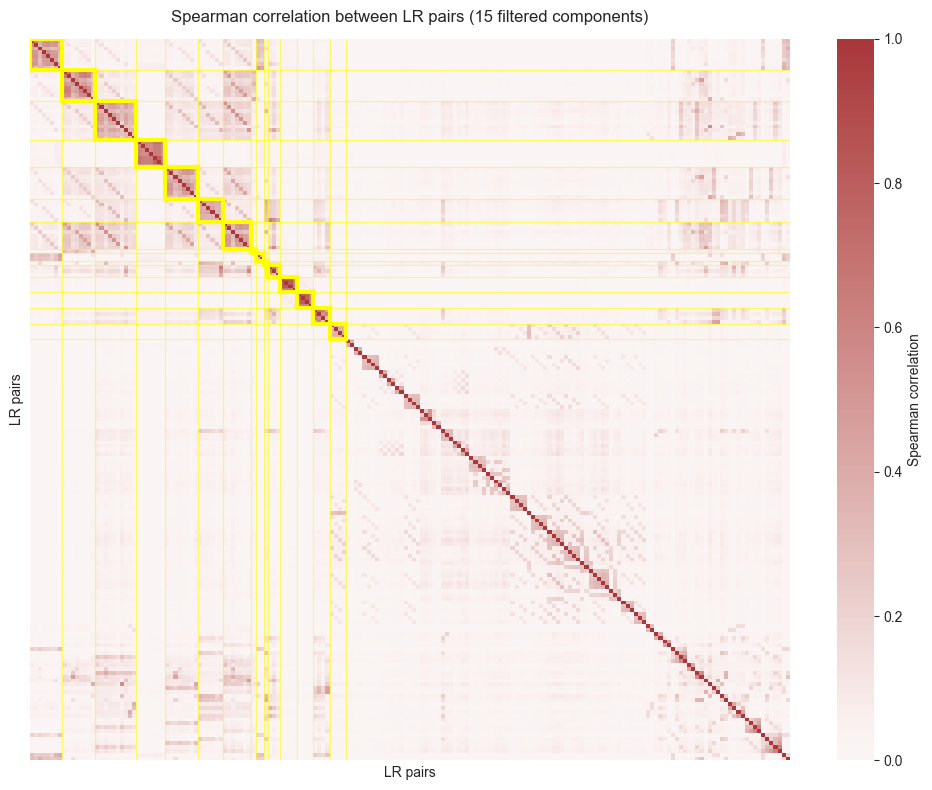

,recommended_dim_envir,num_merged_subsets,subset_sizes,num_lr_pairs,num_graph_edges,num_maximal_cliques_filtered,effective_min_clique_size,num_unassigned_lr_pairs,lr_spearcor_threshold,jaccard_thr,warning
0,15,15,"[8, 8, 10, 7, 8, 6, 7, 4, 4, 4, 4, 4, 4, 4, 4]",185,352,22,4,108,0.3,0.5,None


Recommended dim_envir: 15
Heatmap saved to: D:\SpiderNet\Results\HGSOC\ProcessedData\mi_dimension_selection_LR_spearcorr_heatmap_by_merged_subsets.pdf
Summary JSON saved to: D:\SpiderNet\Results\HGSOC\ProcessedData\mi_dimension_selection_summary.json
Subset summary CSV saved to: D:\SpiderNet\Results\HGSOC\ProcessedData\mi_dimension_selection_merged_subset_summary.csv


In [10]:
from IPython.display import display
import pandas as pd

from SpiderNet.io import load_processed_data
from SpiderNet.MI_dimension_selection import run_mi_dimension_selection

# Optional advanced overrides for MI dimension selection.
# Leave these as None to use the default automatic heuristic.
MI_DIM_LR_SPEARCOR_THRESHOLD = None
MI_DIM_MIN_CLIQUE_SIZE = None
MI_DIM_JACCARD_THRESHOLD = None
MI_DIM_SHOW_HEATMAP = True

processed = load_processed_data(bundle["output_dir"])

print("Processed directory:", bundle["output_dir"])
print("Number of batches:", len(processed.spidernet_data))
print("Number of retained LR pairs:", len(processed.lr_list))
print("Number of training genes:", len(processed.genenames_train))

mi_dim_results = run_mi_dimension_selection(
    processed=processed,
    lr_list=processed.lr_list,
    output_dir=bundle["output_dir"],
    lr_spearcor_threshold=MI_DIM_LR_SPEARCOR_THRESHOLD,
    min_clique_size=MI_DIM_MIN_CLIQUE_SIZE,
    jaccard_thr=MI_DIM_JACCARD_THRESHOLD,
    show=MI_DIM_SHOW_HEATMAP,
)

mi_dim_summary_df = pd.DataFrame(
    [
        {
            "recommended_dim_envir": mi_dim_results["recommended_dim_envir"],
            "num_merged_subsets": mi_dim_results["num_merged_subsets"],
            "subset_sizes": mi_dim_results["subset_sizes"],
            "num_lr_pairs": mi_dim_results["num_lr_pairs"],
            "num_graph_edges": mi_dim_results["num_graph_edges"],
            "num_maximal_cliques_filtered": mi_dim_results["num_maximal_cliques_filtered"],
            "effective_min_clique_size": mi_dim_results["effective_min_clique_size"],
            "num_unassigned_lr_pairs": mi_dim_results["num_unassigned_lr_pairs"],
            "lr_spearcor_threshold": mi_dim_results["lr_spearcor_threshold"],
            "jaccard_thr": mi_dim_results["jaccard_thr"],
            "warning": mi_dim_results["warning"],
        }
    ]
)

display(mi_dim_summary_df)

print(f"Recommended dim_envir: {mi_dim_results['recommended_dim_envir']}")
print(f"Heatmap saved to: {mi_dim_results['heatmap_path']}")
print(f"Summary JSON saved to: {mi_dim_results['summary_path']}")
print(f"Subset summary CSV saved to: {mi_dim_results['subset_summary_path']}")
